In [ ]:
# Importo las librerías para el EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro un estilo limpio para los gráficos
sns.set_theme(style="whitegrid")

# Carga del dataset principal (Pasajeros por molinete) 
df_molinetes = pd.read_csv('data/historico_2021.csv', sep=';')

# 1. Visualizo las primeras 5 filas para entender la estructura
print("--- Primeras filas del dataset ---")
display(df_molinetes.head())

# 2. Obtenemos el resumen técnico: nombres de columnas, nulos y tipos de datos (strings, ints, dates)
print("\n--- Información general del dataset ---")
df_molinetes.info()

--- Primeras filas del dataset ---


,periodo,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL
0,2021,1/1/2021,08:00:00,08:15:00,LineaA,LineaA_Flores_Este_Turn02,Flores,1,0,0,1
1,2021,1/1/2021,08:00:00,08:15:00,LineaA,LineaA_SanPedrito_Oeste_Turn06,San Pedrito,0,0,2,2
2,2021,1/1/2021,08:00:00,08:15:00,LineaB,LineaB_Alem_N_Turn01,Leandro N. Alem,1,0,0,1
3,2021,1/1/2021,08:00:00,08:15:00,LineaB,LineaB_JMRosas_Oeste_Turn05,Rosas,1,0,0,1
4,2021,1/1/2021,08:00:00,08:15:00,LineaB,LineaB_Malabia_N_Turn02,Malabia,1,0,0,1



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 8071680 entries, 0 to 8071679
Data columns (total 11 columns):
 #   Column           Dtype
---  ------           -----
 0   periodo          int64
 1   FECHA            str  
 2   DESDE            str  
 3   HASTA            str  
 4   LINEA            str  
 5   MOLINETE         str  
 6   ESTACION         str  
 7   pax_pagos        int64
 8   pax_pases_pagos  int64
 9   pax_franq        int64
 10  pax_TOTAL        int64
dtypes: int64(5), str(6)
memory usage: 677.4 MB


In [ ]:
# 1. Mostrar la cantidad de valores nulos por cada columna
print("Valores nulos por columna:")
nulos_por_columna = df_molinetes.isnull().sum()
print(nulos_por_columna)

# 2. Convierto la columna de fecha a formato datetime de Pandas
df_molinetes['FECHA'] = pd.to_datetime(df_molinetes['FECHA'], dayfirst=True, errors='coerce')

#  Muestro los tipos de datos para verificar que la conversión fue exitosa
print("\nTipos de datos después de la conversión:")
print(df_molinetes.dtypes)


Valores nulos por columna:
periodo            0
FECHA              0
DESDE              0
HASTA              0
LINEA              0
MOLINETE           0
ESTACION           0
pax_pagos          0
pax_pases_pagos    0
pax_franq          0
pax_TOTAL          0
dtype: int64

Tipos de datos después de la conversión:
periodo                     int64
FECHA              datetime64[us]
DESDE                         str
HASTA                         str
LINEA                         str
MOLINETE                      str
ESTACION                      str
pax_pagos                   int64
pax_pases_pagos             int64
pax_franq                   int64
pax_TOTAL                   int64
dtype: object


--- Estadísticas Descriptivas (Pasajeros) ---


,pax_pagos,pax_TOTAL
count,8071680.00,8071680.00
mean,11.28,11.90
std,14.59,14.92
min,0.00,1.00
25%,2.00,3.00
50%,7.00,7.00
75%,15.00,16.00
max,292.00,298.00


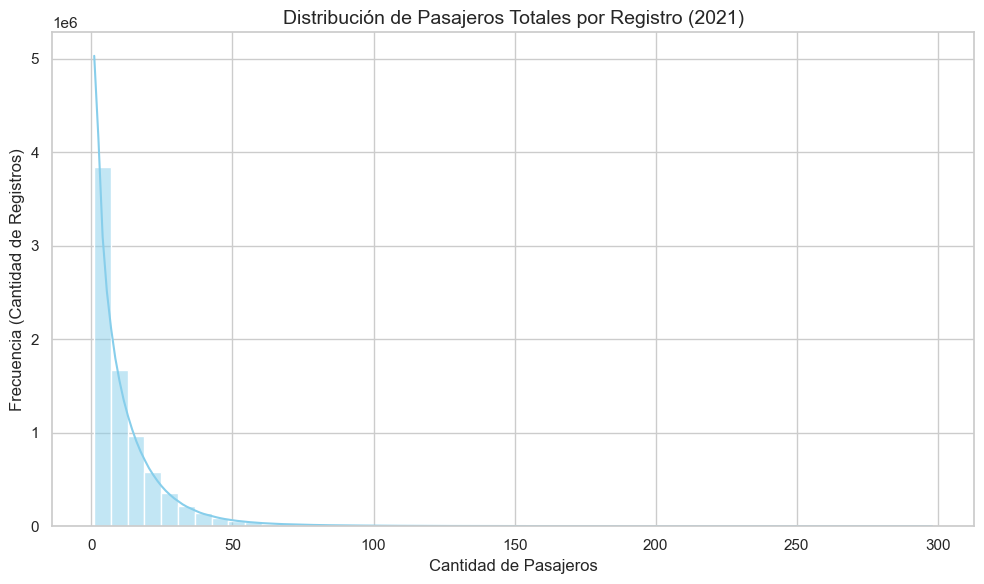

In [6]:
# 1. Estadísticas descriptivas de las variables
print("--- Estadísticas Descriptivas (Pasajeros) ---")
# Usamos el formato para evitar notación científica y hacerlo más legible
display(df_molinetes[['pax_pagos', 'pax_TOTAL']].describe().apply(lambda s: s.apply('{0:.2f}'.format)))

# 2. Primera Visualización: Histograma de distribución de pasajeros
plt.figure(figsize=(10, 6))
# Filtramos un poco los datos extremos (si los hay) para que el gráfico sea más claro
sns.histplot(data=df_molinetes[df_molinetes['pax_TOTAL'] > 0], x='pax_TOTAL', bins=50, kde=True, color='skyblue')

plt.title('Distribución de Pasajeros Totales por Registro (2021)', fontsize=14)
plt.xlabel('Cantidad de Pasajeros', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Registros)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\enzoc\AppData\Local\Temp\ipykernel_27728\268343651.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_10, x='pax_TOTAL', y='ESTACION', palette='magma')


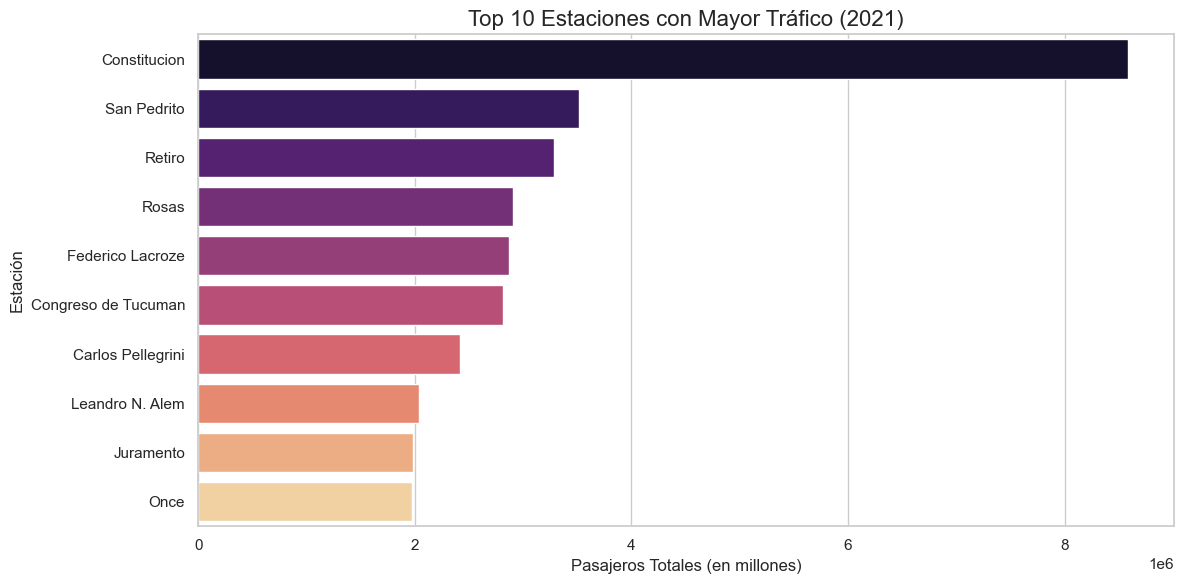

In [7]:
# 1. Agrupamos por ESTACION sumando los pasajeros totales
df_trafico_estaciones = df_molinetes.groupby('ESTACION')['pax_TOTAL'].sum().reset_index()

# 2. Ordenamos de mayor a menor y nos quedamos con el Top 10
df_top_10 = df_trafico_estaciones.sort_values(by='pax_TOTAL', ascending=False).head(10)

# 3. Graficamos con Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_10, x='pax_TOTAL', y='ESTACION', palette='magma')

plt.title('Top 10 Estaciones con Mayor Tráfico (2021)', fontsize=16)
plt.xlabel('Pasajeros Totales (en millones)', fontsize=12)
plt.ylabel('Estación', fontsize=12)
plt.tight_layout()
plt.show()

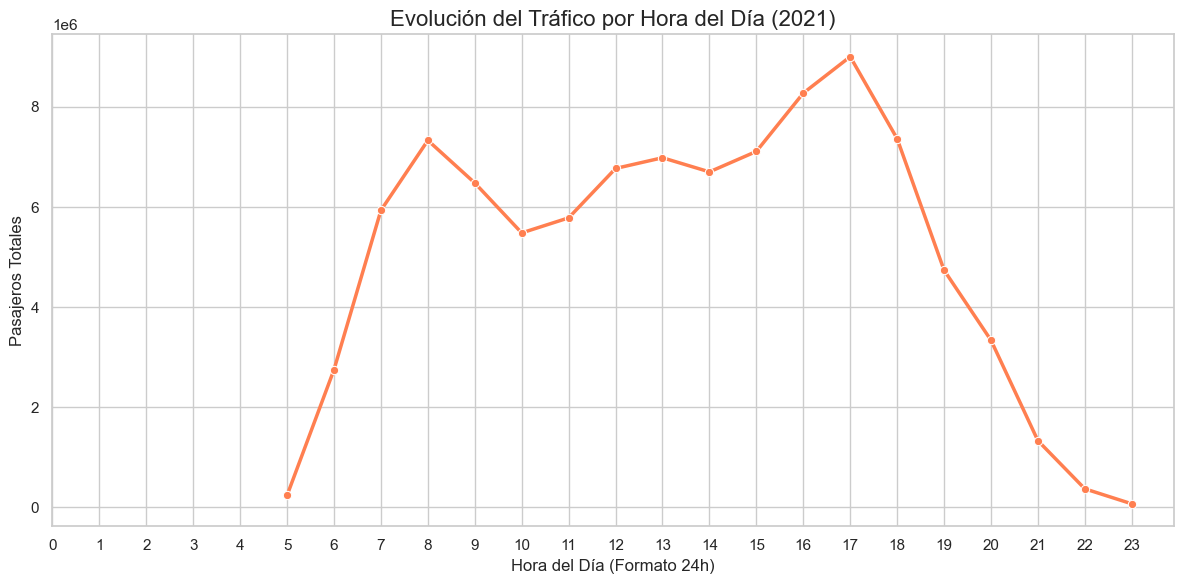

In [8]:
# 1. Extraigo solo la hora de la columna 'DESDE' y la paso a tipo numérico entero
df_molinetes['hora'] = df_molinetes['DESDE'].str[:2].astype(int)

# 2. Agrupo los pasajeros totales por cada hora del día
df_trafico_hora = df_molinetes.groupby('hora')['pax_TOTAL'].sum().reset_index()

# 3. Visualizo la evolución del tráfico con un gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trafico_hora, x='hora', y='pax_TOTAL', marker='o', color='coral', linewidth=2.5)

plt.title('Evolución del Tráfico por Hora del Día (2021)', fontsize=16)
plt.xlabel('Hora del Día (Formato 24h)', fontsize=12)
plt.ylabel('Pasajeros Totales', fontsize=12)
plt.xticks(range(0, 24)) 
plt.tight_layout()
plt.show()

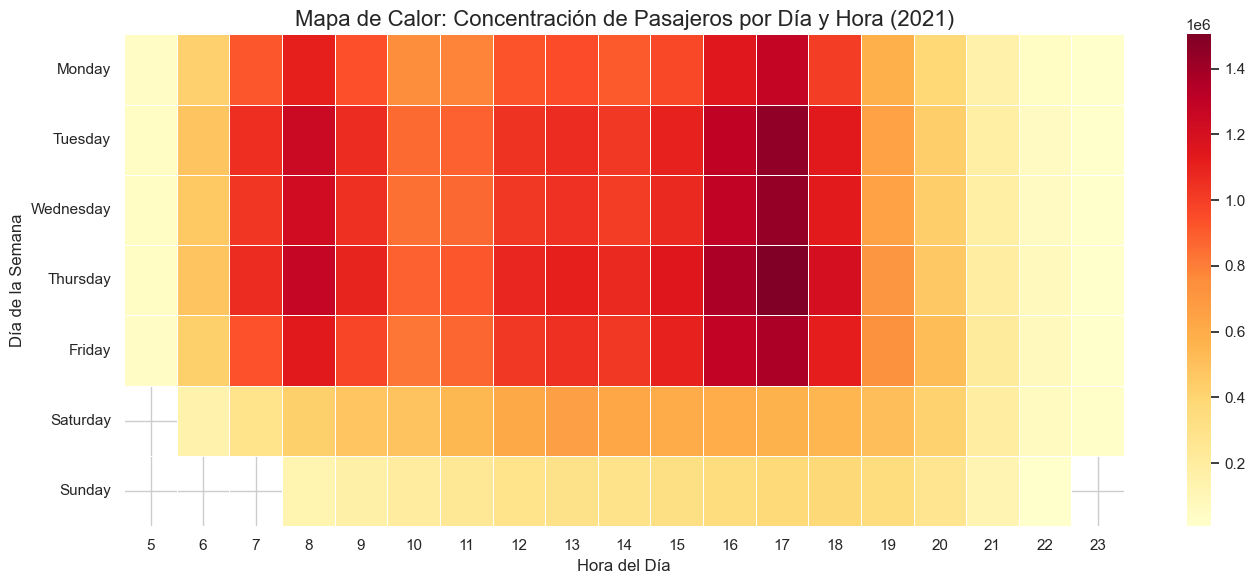

In [9]:
# Extraigo el nombre del día de la semana de la columna FECHA
df_molinetes['dia_semana'] = df_molinetes['FECHA'].dt.day_name()

# Defino el orden lógico de los días para que el gráfico se lea correctamente de lunes a domingo
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_molinetes['dia_semana'] = pd.Categorical(df_molinetes['dia_semana'], categories=orden_dias, ordered=True)

# Agrupo los datos creando una tabla dinámica (pivot table) cruzando días, horas y sumando los pasajeros
df_heatmap = df_molinetes.pivot_table(index='dia_semana', columns='hora', values='pax_TOTAL', aggfunc='sum')

# Genero el mapa de calor utilizando Seaborn
plt.figure(figsize=(14, 6))
sns.heatmap(df_heatmap, cmap='YlOrRd', linewidths=.5)

plt.title('Mapa de Calor: Concentración de Pasajeros por Día y Hora (2021)', fontsize=16)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\enzoc\AppData\Local\Temp\ipykernel_27728\1808552517.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='dia_semana', y='pax_TOTAL', palette='Set2')


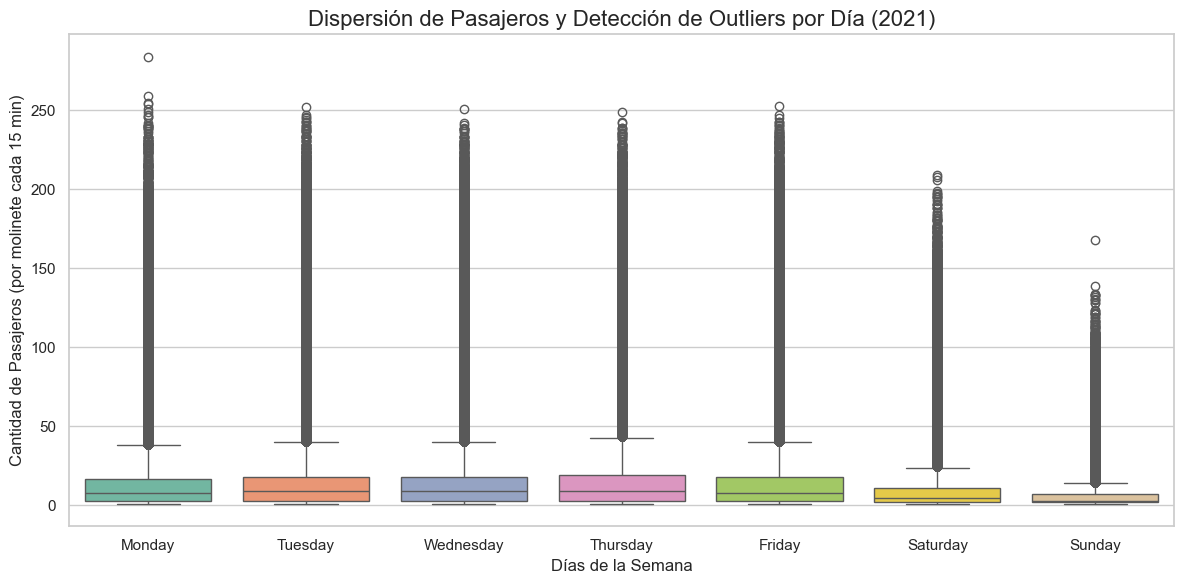

In [11]:
# Genero un diagrama boxplot para analizar la dispersión de los datos
plt.figure(figsize=(12, 6))
# Filtro los registros sin pasajeros para que la caja no se aplaste contra el cero
df_filtrado = df_molinetes[df_molinetes['pax_TOTAL'] > 0]
sns.boxplot(data=df_filtrado, x='dia_semana', y='pax_TOTAL', palette='Set2')

plt.title('Dispersión de Pasajeros y Detección de Outliers por Día (2021)', fontsize=16)
plt.xlabel('Días de la Semana', fontsize=12)
plt.ylabel('Cantidad de Pasajeros (por molinete cada 15 min)', fontsize=12)
plt.tight_layout()
plt.show()